In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Import Libraries

In [69]:
import os
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import json
import shutil
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import callbacks
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, BatchNormalization, Dense, Input, Flatten
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model

# Load Dataset

In [2]:
# Path of dataset
dataset_path = "/kaggle/input/datasets/salmansajid05/oral-diseases"

# Classes Name
classes = ['Calculus', 'Caries','Gingivitis','Mouth_Ulcer','Tooth Discoloration','Hypodontia']

In [3]:
# Collect image paths and labels
image_paths = []
labels = []

# Calculus
calculus_path = os.path.join(dataset_path, "Calculus", "Calculus")

for img in os.listdir(calculus_path):
    image_paths.append(os.path.join(calculus_path, img))
    labels.append("Calculus")


# Caries (Original Dataset)
caries_path = os.path.join(
    dataset_path,
    "Data caries",
    "Data caries",
    "caries orignal data set",
    "done"
)

for img in os.listdir(caries_path):
    image_paths.append(os.path.join(caries_path, img))
    labels.append("Caries")


# Gingivitis
gingivitis_path = os.path.join(dataset_path, "Gingivitis", "Gingivitis")

for img in os.listdir(gingivitis_path):
    image_paths.append(os.path.join(gingivitis_path, img))
    labels.append("Gingivitis")


# Mouth Ulcer (Original Dataset)
ulcer_path = os.path.join(
    dataset_path,
    "Mouth Ulcer",
    "Mouth Ulcer",
    "ulcer original dataset",
    "ulcer original dataset"
)

for img in os.listdir(ulcer_path):
    image_paths.append(os.path.join(ulcer_path, img))
    labels.append("Mouth_Ulcer")


# Tooth Discoloration (Original Dataset)
discoloration_path = os.path.join(
    dataset_path,
    "Tooth Discoloration",
    "Tooth Discoloration ",
    "tooth discoloration original dataset",
    "tooth discoloration original dataset"
)

for img in os.listdir(discoloration_path):
    image_paths.append(os.path.join(discoloration_path, img))
    labels.append("Tooth Discoloration")


# Hypodontia
hypodontia_path = os.path.join(dataset_path, "hypodontia", "hypodontia")

for img in os.listdir(hypodontia_path):
    image_paths.append(os.path.join(hypodontia_path, img))
    labels.append("Hypodontia")

In [4]:
# Convert it to Dataframe
oral_df = pd.DataFrame({
    "image_path": image_paths,
    "label" : labels
})

oral_df.head(10)

,image_path,label
0,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
1,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
2,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
3,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
4,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
5,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
6,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
7,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
8,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus
9,/kaggle/input/datasets/salmansajid05/oral-dise...,Calculus


# EDA & Preprocessing

In [5]:
# Show number of image with its label
print("- Total Images: ", len(oral_df))
print("- Number of Classes: ",oral_df['label'].nunique())
print('\n',oral_df['label'].value_counts())

- Total Images:  5563
- Number of Classes:  6

 label
Gingivitis             2349
Calculus               1296
Hypodontia             1251
Mouth_Ulcer             265
Caries                  219
Tooth Discoloration     183
Name: count, dtype: int64


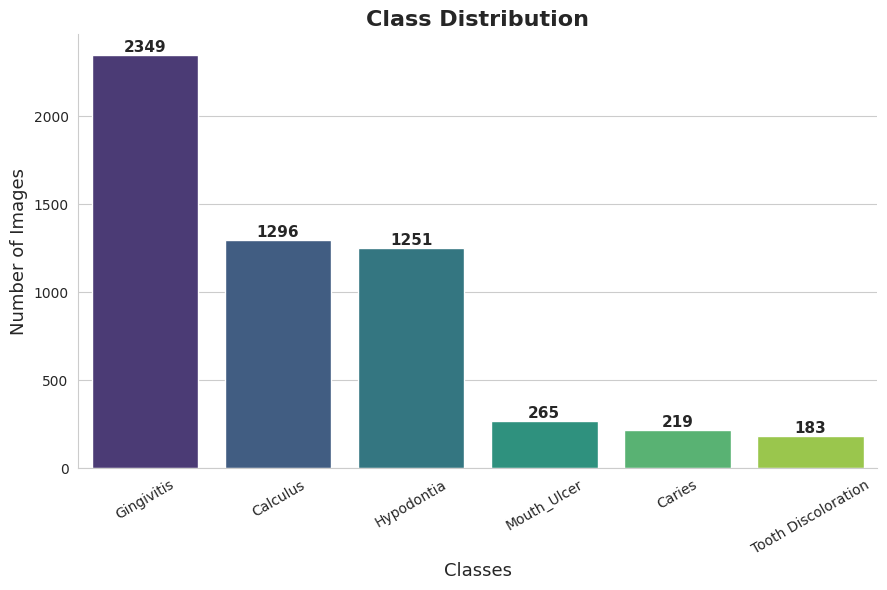

In [6]:
# Class Distribution
sns.set_style("whitegrid")

class_counts = oral_df["label"].value_counts()

plt.figure(figsize=(9,6))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette="viridis"
)

plt.title("Class Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Classes", fontsize=13)
plt.ylabel("Number of Images", fontsize=13)
plt.xticks(rotation=30)

# Display values
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

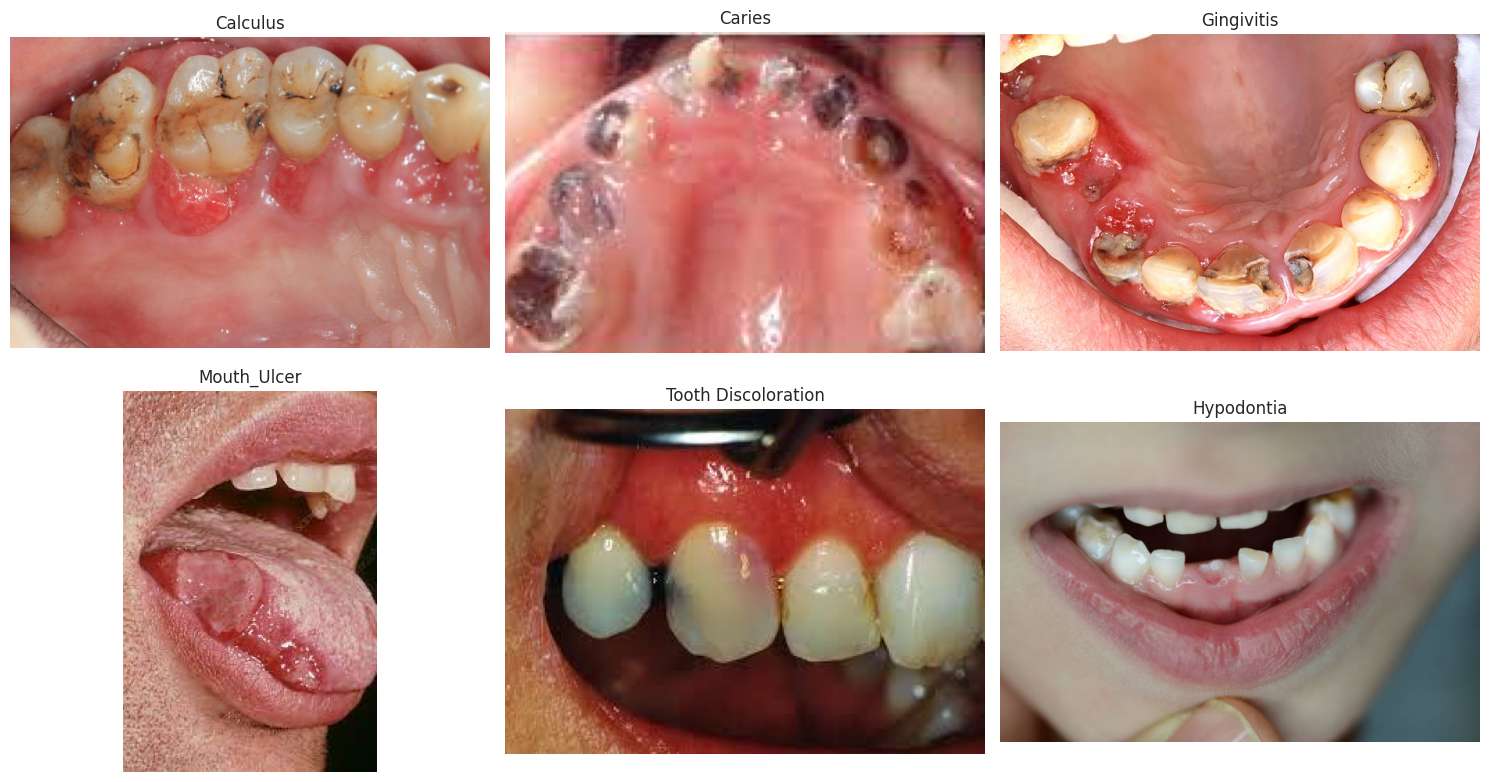

In [7]:
# Display one sample from each class
classes = oral_df["label"].unique()

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    img_path = oral_df[oral_df["label"] == cls]["image_path"].iloc[0]
    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Determine size and channel of images in each class
for cls in classes:
    img_path = oral_df[oral_df["label"] == cls]["image_path"].iloc[0]
    img = Image.open(img_path)

    print(f"Class: {cls}")
    print("Size :", img.size)
    print("mode :", img.mode)
    print("-"*30)

Class: Calculus
Size : (612, 397)
mode : RGB
------------------------------
Class: Caries
Size : (175, 117)
mode : RGBA
------------------------------
Class: Gingivitis
Size : (612, 404)
mode : RGB
------------------------------
Class: Mouth_Ulcer
Size : (183, 275)
mode : RGB
------------------------------
Class: Tooth Discoloration
Size : (265, 190)
mode : RGB
------------------------------
Class: Hypodontia
Size : (612, 408)
mode : RGB
------------------------------


In [9]:
# Divide dataset to train, val, test 
train_df, train_dff = train_test_split(
    oral_df,
    test_size=0.30,
    stratify=oral_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    train_dff,
    test_size=0.50,
    stratify=train_dff["label"],
    random_state=42
)

In [10]:
print(f"Train data size: {len(train_df)} images")
print(f"Validation data size: {len(val_df)} images")
print(f"Test data size: {len(test_df)} images")

Train data size: 3894 images
Validation data size: 834 images
Test data size: 835 images


In [11]:
# Define hyper-parameters, image dimensions, and map class names to integer labels
Batch_size = 32
Image_width = 224
Image_height = 224
Image_size = (Image_width, Image_height)

Epochs = 100

class_names = sorted(oral_df["label"].unique())
Num_classes = len(class_names)

label_encoder = {label: i for i, label in enumerate(class_names)}

print(label_encoder)

{'Calculus': 0, 'Caries': 1, 'Gingivitis': 2, 'Hypodontia': 3, 'Mouth_Ulcer': 4, 'Tooth Discoloration': 5}


In [13]:
# Preprocess input images for the custom CNN model
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)

    # Convert image to RGB 
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(image, Image_size)

    # Normalize (0-255 --> 0-1)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [12]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", input_shape=(224, 224, 3)),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
])

I0000 00:00:1784031394.265439      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [13]:
# Encode dataset labels into numerical values
train_labels = train_df["label"].map(label_encoder).values
val_labels = val_df["label"].map(label_encoder).values
test_labels = test_df["label"].map(label_encoder).values

In [14]:
# Extract image file paths from the datasets
train_paths = train_df["image_path"].values
val_paths = val_df["image_path"].values
test_paths = test_df["image_path"].values

In [17]:
# Create tensor Dataset 
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [18]:
# Apply preprocessing function
train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)
test_ds = test_ds.map(preprocess_image)

In [20]:
# Shuffle (Train only) 
train_ds = train_ds.shuffle(buffer_size=len(train_df))

In [21]:
# Batch size
train_ds = train_ds.batch(Batch_size)
val_ds = val_ds.batch(Batch_size)
test_ds = test_ds.batch(Batch_size)

In [22]:
# Prefetch
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = AUTOTUNE)

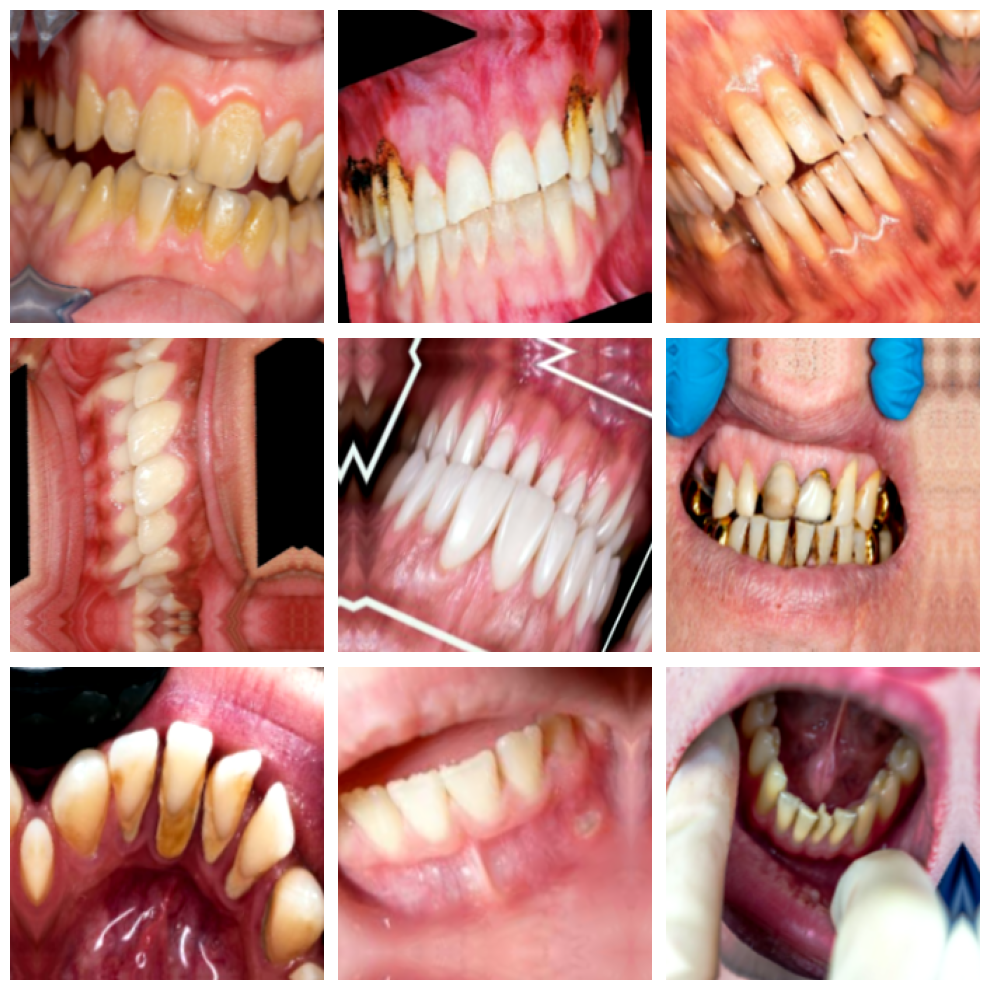

In [25]:
# Batch fetching
image_batch, label_batch = next(iter(train_ds))

# Apply augmentation
augmented_images = data_augmentation(image_batch, training=True)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    
    # Convert tensor to numpy
    img = augmented_images[i].numpy()
    
    # clipping
    img_clipped = np.clip(img, 0.0, 1.0)
    
    plt.imshow(img_clipped)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [26]:
# Show image size
for images, labels in train_ds.take(1):
    print(f"Image size: {images.shape}")
    print(f"Label size: {labels.shape}")

Image size: (32, 224, 224, 3)
Label size: (32,)


In [27]:
# Reduce learning rate when validation accuracy plateaus
lr_callback = ReduceLROnPlateau(
    monitor="val_accuracy", 
    factor=0.1, 
    patience=8,
    mode="max",
    verbose=1
)

# Stop training early when validation accuracy stops improving
stop_callbacks = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True
)

# Save the best model based on validation accuracy
model_checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# Custom CNN Model

In [28]:
# Model
cnn_model = Sequential([

    Input(shape=(Image_height, Image_width, 3)),

    data_augmentation,

    # Block 1
    Conv2D(32, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    Conv2D(32, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    MaxPooling2D((2,2)),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    Conv2D(64, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # Block 3
    Conv2D(128, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    Conv2D(128, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    MaxPooling2D((2,2)),
    Dropout(0.4),

    # Block 4
    Conv2D(256, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    Conv2D(256, (3,3), activation="relu", padding="same",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    
    MaxPooling2D((2,2)),
    Dropout(0.4),

    GlobalAveragePooling2D(),

    Dense(512, activation="relu",kernel_regularizer=l2(1e-4)),
    Dropout(0.5),

    Dense(256, activation="relu",kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(Num_classes, activation="softmax")
])

In [29]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,440,550 (5.50 MB)

 Trainable params: 1,438,630 (5.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [30]:
# Compile model with Adam optimizer, sparse categorical loss, and accuracy
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
# Train model 
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=Epochs,
    callbacks=[lr_callback, stop_callbacks, model_checkpoint]
)

Epoch 1/100


E0000 00:00:1783982032.347987      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4365 - loss: 1.6281
Epoch 1: val_accuracy improved from None to 0.08993, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 41s 206ms/step - accuracy: 0.4944 - loss: 1.4688 - val_accuracy: 0.0899 - val_loss: 2.6751 - learning_rate: 0.0010
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5812 - loss: 1.2369
Epoch 2: val_accuracy did not improve from 0.08993
122/122 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.5822 - loss: 1.2047 - val_accuracy: 0.0803 - val_loss: 5.1849 - learning_rate: 0.0010
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6148 - loss: 1.1006
Epoch 3: val_accuracy improved from 0.08993 to 0.29376, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.6135 - loss: 1.1041 - val_accuracy: 0.2938 - val_loss: 3.1210 - learn

In [32]:
# Evaluation on test set
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.7784 - loss: 0.6711
Test Accuracy: 0.7784
Test Loss: 0.6711


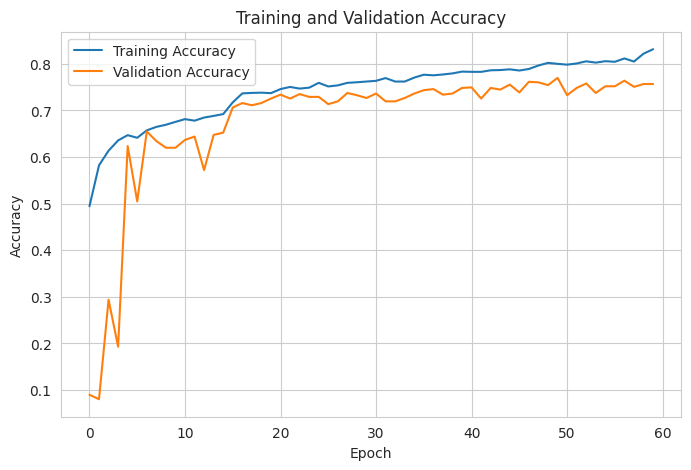

In [33]:
# Training & Validation accuracy Plot
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

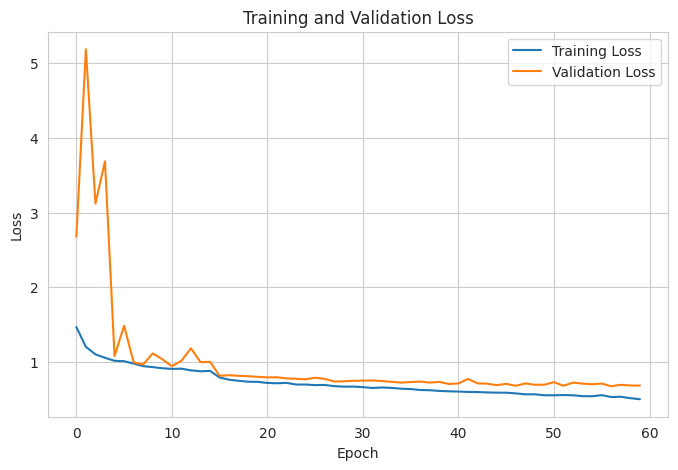

In [34]:
# Training & Validation Loss Plot
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [35]:
# True Labels
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Prediction
y_pred = cnn_model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [36]:
# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                     precision    recall  f1-score   support

           Calculus       0.67      0.72      0.69       195
             Caries       0.67      0.18      0.29        33
         Gingivitis       0.80      0.82      0.81       353
         Hypodontia       0.85      0.90      0.88       188
        Mouth_Ulcer       0.89      0.82      0.85        39
Tooth Discoloration       0.61      0.52      0.56        27

           accuracy                           0.78       835
          macro avg       0.75      0.66      0.68       835
       weighted avg       0.78      0.78      0.77       835



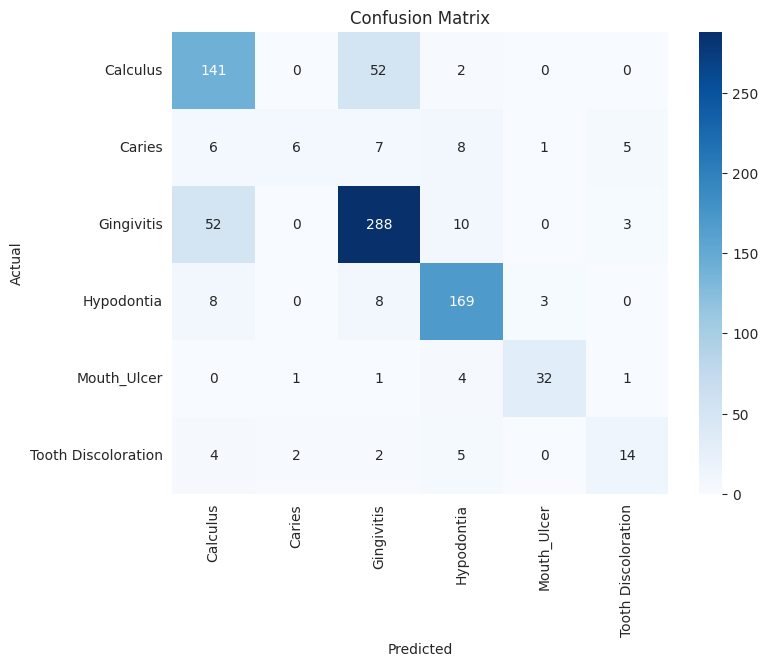

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [38]:
# Calculate Precision, Recall, F1_score
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.7758704266387204
Recall    : 0.7784431137724551
F1 Score  : 0.771099839981558


In [39]:
# Save Results
cnn_results = {
    "Accuracy": test_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [41]:
# Save Time and Memory
del cnn_model

gc.collect()
tf.keras.backend.clear_session()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Pre_Trained models 


## ResNet50

In [15]:
# Preprocess images for the ResNet model
def preprocess_resnet(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, (224, 224))

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [16]:
# Configure autotune 
AUTOTUNE = tf.data.AUTOTUNE

train_ds_resnet = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds_resnet = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds_resnet = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

In [17]:
# Apply Preprocessing in parallel
train_ds_resnet = train_ds_resnet.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
)

val_ds_resnet = val_ds_resnet.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
)

test_ds_resnet = test_ds_resnet.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
)

In [18]:
# Shuffle and Batch
train_ds_resnet = train_ds_resnet.shuffle(len(train_df))

train_ds_resnet = train_ds_resnet.batch(Batch_size)
val_ds_resnet = val_ds_resnet.batch(Batch_size)
test_ds_resnet = test_ds_resnet.batch(Batch_size)

In [19]:
# Prefetch
train_ds_resnet = train_ds_resnet.prefetch(AUTOTUNE)

val_ds_resnet = val_ds_resnet.prefetch(AUTOTUNE)

test_ds_resnet = test_ds_resnet.prefetch(AUTOTUNE)

In [20]:
# Load pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# Build model
inputs = Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256,activation="relu",kernel_regularizer=l2(1e-4))(x)

x = Dropout(0.4)(x)

outputs = Dense(Num_classes, activation="softmax")(x)

resnet_model = Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,990 (92.02 MB)

 Trainable params: 530,182 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [22]:
# Compile model with Adam optimizer, sparse categorical loss, and accuracy
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
# Reduce learning rate when validation accuracy plateaus
lr_callback_resnet = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.1,
    patience=8,
    mode="max",
    verbose=1
)

# Stop training early when validation accuracy stops improving
early_stop_resnet = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    mode="max"
)

# Save the best model based on validation accuracy
checkpoint_resnet = ModelCheckpoint(
    "best_resnet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [24]:
# Train resnet_model 
history_resnet = resnet_model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=Epochs,
    callbacks=[
        lr_callback_resnet,
        early_stop_resnet,
        checkpoint_resnet
    ]
)

Epoch 1/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3494 - loss: 2.0353
Epoch 1: val_accuracy improved from None to 0.66547, saving model to best_resnet.keras

Epoch 1: finished saving model to best_resnet.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - accuracy: 0.4576 - loss: 1.6430 - val_accuracy: 0.6655 - val_loss: 0.9047 - learning_rate: 1.0000e-04
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6113 - loss: 1.1342
Epoch 2: val_accuracy improved from 0.66547 to 0.70264, saving model to best_resnet.keras

Epoch 2: finished saving model to best_resnet.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.6220 - loss: 1.0906 - val_accuracy: 0.7026 - val_loss: 0.7997 - learning_rate: 1.0000e-04
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6656 - loss: 0.9444
Epoch 3: val_accuracy improved from 0.70264 to 0.71703, saving model to best_resnet.keras

Epoch 3: finished saving model to best_resnet.keras
122/122 ━━━━━━

In [25]:
# Evaluation on test dataset
test_loss_resnet, test_accuracy_resnet = resnet_model.evaluate(test_ds_resnet)

print(f"Test Accuracy : {test_accuracy_resnet:.4f}")
print(f"Test Loss : {test_loss_resnet:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7964 - loss: 0.5860
Test Accuracy : 0.7964
Test Loss : 0.5860


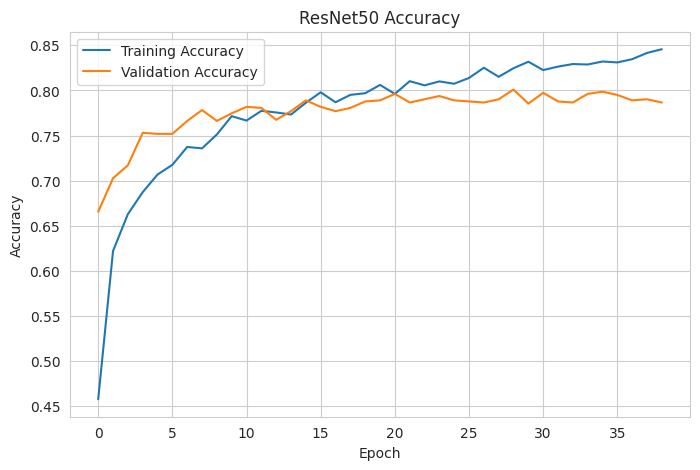

In [26]:
# Training & Validation accuracy Plot
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history["accuracy"], label="Training Accuracy")
plt.plot(history_resnet.history["val_accuracy"], label="Validation Accuracy")

plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

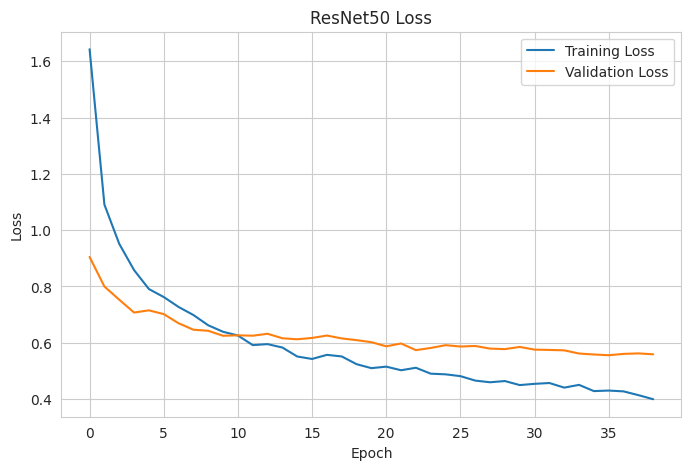

In [27]:
# Training & Validation Loss Plot
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history["loss"], label="Training Loss")
plt.plot(history_resnet.history["val_loss"], label="Validation Loss")

plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
# True Labels
y_true = []

for images, labels in test_ds_resnet:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Prediction
y_pred_resnet = resnet_model.predict(test_ds_resnet)
y_pred_resnet = np.argmax(y_pred_resnet, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step


In [30]:
# Classification Report
print(classification_report(
    y_true,
    y_pred_resnet,
    target_names=class_names
))

                     precision    recall  f1-score   support

           Calculus       0.65      0.68      0.67       195
             Caries       0.90      0.55      0.68        33
         Gingivitis       0.79      0.82      0.81       353
         Hypodontia       0.93      0.91      0.92       188
        Mouth_Ulcer       0.88      0.97      0.93        39
Tooth Discoloration       0.83      0.56      0.67        27

           accuracy                           0.80       835
          macro avg       0.83      0.75      0.78       835
       weighted avg       0.80      0.80      0.80       835



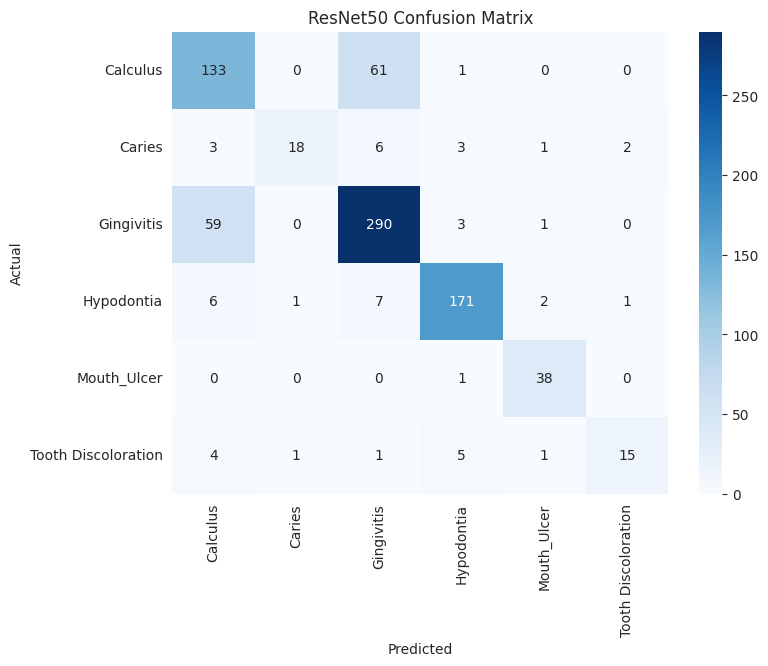

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_resnet)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

plt.show()

In [32]:
# Precision, Recall, F1_score
precision_resnet = precision_score(
    y_true,
    y_pred_resnet,
    average="weighted"
)

recall_resnet = recall_score(
    y_true,
    y_pred_resnet,
    average="weighted"
)

f1_resnet = f1_score(
    y_true,
    y_pred_resnet,
    average="weighted"
)

print("Precision :", precision_resnet)
print("Recall    :", recall_resnet)
print("F1 Score  :", f1_resnet)

Precision : 0.8004316839880555
Recall    : 0.7964071856287425
F1 Score  : 0.7954830524827247


In [72]:
# Save Time and Memory
del resnet_model

gc.collect()
tf.keras.backend.clear_session()

## EfficientNetB0

In [34]:
# Preprocess images for the EfficientNet model
def preprocess_efficient(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, (224, 224))

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [35]:
# Configure autotune 
AUTOTUNE = tf.data.AUTOTUNE

train_ds_eff = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds_eff = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds_eff = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

In [36]:
# Apply preprocessing function in parallel
train_ds_eff = train_ds_eff.map(
    preprocess_efficient,
    num_parallel_calls=AUTOTUNE
)

val_ds_eff = val_ds_eff.map(
    preprocess_efficient,
    num_parallel_calls=AUTOTUNE
)

test_ds_eff = test_ds_eff.map(
    preprocess_efficient,
    num_parallel_calls=AUTOTUNE
)

In [37]:
# Apply Shuffle, Batch and Prefetch
train_ds_eff = train_ds_eff.shuffle(len(train_df))

train_ds_eff = train_ds_eff.batch(Batch_size).prefetch(AUTOTUNE)

val_ds_eff = val_ds_eff.batch(Batch_size).prefetch(AUTOTUNE)

test_ds_eff = test_ds_eff.batch(Batch_size).prefetch(AUTOTUNE)

In [38]:
# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256,activation="relu",kernel_regularizer=l2(1e-4))(x)

x = Dropout(0.4)(x)

outputs = Dense(Num_classes, activation="softmax")(x)

efficientnet_model = Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
efficientnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,169 (16.72 MB)

 Trainable params: 332,038 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [40]:
# Compile model with Adam optimizer, sparse categorical loss, and accuracy
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [41]:
# Reduce learning rate when validation accuracy plateaus
lr_callback_eff = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.1,
    patience=8,
    mode="max",
    verbose=1
)

# Stop training early when validation accuracy stops improving
early_stop_eff = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    mode="max"
)

# Save the best model based on validation accuracy
checkpoint_eff = ModelCheckpoint(
    "best_efficientnet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [42]:
# Train efficientnet_model
history_eff = efficientnet_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=Epochs,
    callbacks=[
        lr_callback_eff,
        early_stop_eff,
        checkpoint_eff
    ]
)

Epoch 1/100


E0000 00:00:1784034399.342626      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3356 - loss: 2.0298
Epoch 1: val_accuracy improved from None to 0.64508, saving model to best_efficientnet.keras

Epoch 1: finished saving model to best_efficientnet.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 27s 101ms/step - accuracy: 0.4538 - loss: 1.6305 - val_accuracy: 0.6451 - val_loss: 1.0080 - learning_rate: 1.0000e-04
Epoch 2/100
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5848 - loss: 1.1690
Epoch 2: val_accuracy improved from 0.64508 to 0.68345, saving model to best_efficientnet.keras

Epoch 2: finished saving model to best_efficientnet.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.6150 - loss: 1.0900 - val_accuracy: 0.6835 - val_loss: 0.8051 - learning_rate: 1.0000e-04
Epoch 3/100
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6653 - loss: 0.9395
Epoch 3: val_accuracy improved from 0.68345 to 0.71703, saving model to best_efficientnet.keras

Epoch 3: finished saving model to best_efficientn

In [43]:
# Evaluation on test dataset
test_loss_eff, test_accuracy_eff = efficientnet_model.evaluate(test_ds_eff)

print(f"Test Accuracy: {test_accuracy_eff:.4f}")
print(f"Test Loss : {test_loss_eff:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8012 - loss: 0.5101
Test Accuracy: 0.8012
Test Loss : 0.5101


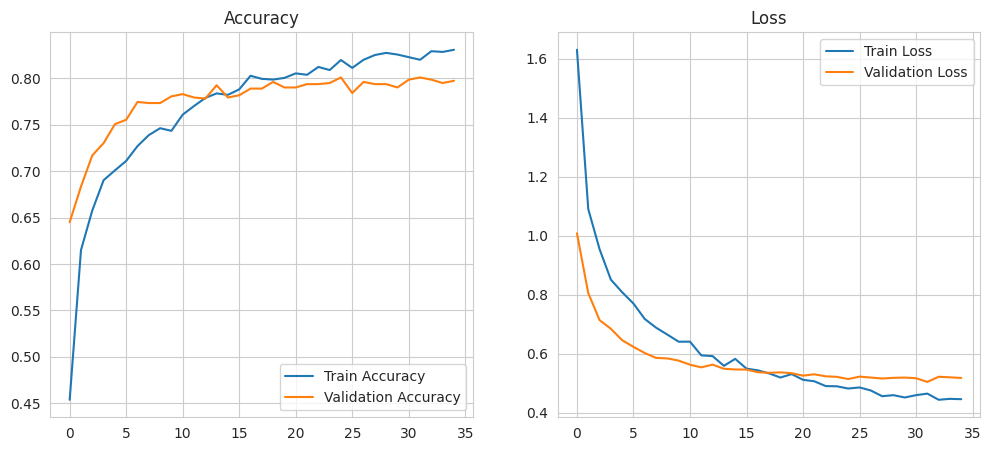

In [44]:
# Training & Validation Accuracy, Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_eff.history["accuracy"], label="Train Accuracy")
plt.plot(history_eff.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history_eff.history["loss"], label="Train Loss")
plt.plot(history_eff.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [48]:
# True Labels
y_true = np.concatenate([
    labels.numpy() for _, labels in test_ds_eff
])

# Prediction
y_pred_prob = efficientnet_model.predict(test_ds_eff)

y_pred = np.argmax(y_pred_prob, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [49]:
# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                     precision    recall  f1-score   support

           Calculus       0.71      0.60      0.65       195
             Caries       0.59      0.48      0.53        33
         Gingivitis       0.76      0.88      0.82       353
         Hypodontia       0.97      0.91      0.94       188
        Mouth_Ulcer       0.95      0.90      0.92        39
Tooth Discoloration       0.94      0.63      0.76        27

           accuracy                           0.80       835
          macro avg       0.82      0.74      0.77       835
       weighted avg       0.80      0.80      0.80       835



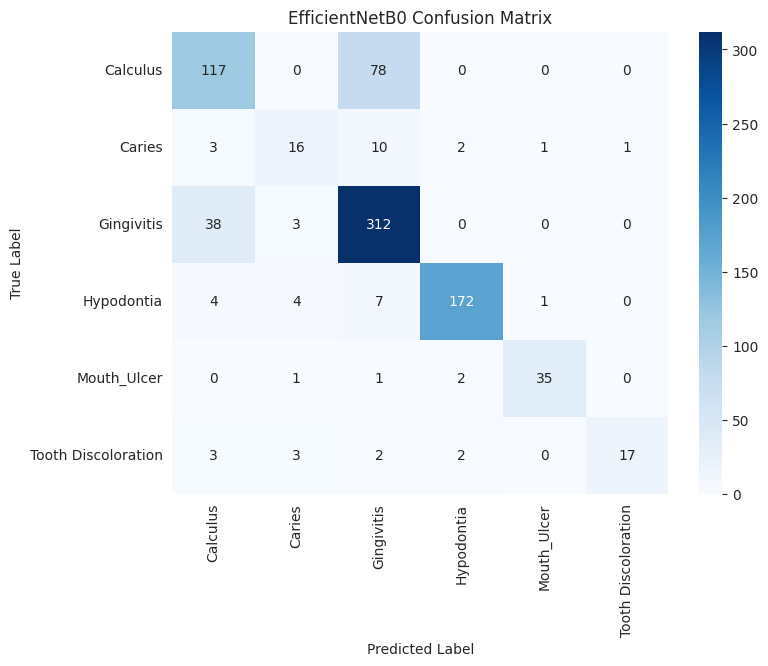

In [50]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")

plt.show()

In [51]:
# Precision, Recall, F1_score
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision Percentage : {precision:.4f}")
print(f"Recall Percentage : {recall:.4f}")
print(f"F1_Score Percentage : {f1:.4f}")

Precision Percentage : 0.8030
Recall Percentage : 0.8012
F1_Score Percentage : 0.7977


In [3]:
# Test for the model 
image_path = "/kaggle/input/datasets/salmansajid05/oral-diseases/Calculus/Calculus/(1021).jpg"

class_names = [
    "Calculus",
    "Caries",
    "Gingivitis",
    "Hypodontia",
    "Mouth_Ulcer",
    "Tooth Discoloration"
]

# Read and prepare the image
image = tf.io.read_file(image_path)
image = tf.image.decode_image(image, channels=3, expand_animations=False)
image = tf.image.resize(image, (224, 224))
image = tf.cast(image, tf.float32)
image = preprocess_input(image)

# Add Batch
image_batch = tf.expand_dims(image, axis=0)

# Prediction
prediction = efficientnet_model.predict(image_batch, verbose=0)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show the original image
original_image = tf.keras.utils.load_img(image_path)

plt.figure(figsize=(6,6))
plt.imshow(original_image)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()

In [56]:
# Save Model and Class names 
efficientnet_model.save("/kaggle/working/best_efficientnet.keras")

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

In [57]:
# Convert model into ZIP file
shutil.make_archive(
    "/kaggle/working/best_efficientnet",
    "zip",
    "/kaggle/working",
    "best_efficientnet.keras"
)

'/kaggle/working/best_efficientnet.zip'

In [74]:
# Save random images
selected_images = [
    "/kaggle/input/datasets/salmansajid05/oral-diseases/hypodontia/hypodontia/(1003).JPG",
    "/kaggle/input/datasets/salmansajid05/oral-diseases/Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset/116.jpg",
    "/kaggle/input/datasets/salmansajid05/oral-diseases/Data caries/Data caries/caries orignal data set/done/0.jpg",
    "/kaggle/input/datasets/salmansajid05/oral-diseases/Data caries/Data caries/caries orignal data set/done/103.jpg",
    "/kaggle/input/datasets/salmansajid05/oral-diseases/Gingivitis/Gingivitis/(104).jpg",
    "/kaggle/input/datasets/salmansajid05/oral-diseases/Gingivitis/Gingivitis/(1043).jpg",
    "/kaggle/input/datasets/salmansajid05/oral-diseases/Calculus/Calculus/(1021).jpg",
    "/kaggle/input/datasets/salmansajid05/oral-diseases/Calculus/Calculus/(1027).jpg"
    
]

output_folder = "/kaggle/working/my_selected_images"
os.makedirs(output_folder, exist_ok=True)

for img_path in selected_images:
    if os.path.exists(img_path):
        shutil.copy(img_path, output_folder)
    else:
        print(f"File not found: {img_path}")

print("Images saved successfully!")

Images saved successfully!
